# Langraph Tutorial

## Langraph Elements

### State
- The state is shared data structure that holds the current information or context of the entire application
- Assume it like a application's memory, keeping track of all variables and data which can be accessed and modified by all the nodes of worflow

### Nodes
- Nodes are individual fucntions or operations that perform specific tasks within graph
- Each node receives input, it can check the memory accessing states, run over it, and generate output or just modify the state. 

### Graph
- A graph in LanGraph is a structure which consists of different different nodes connected to each other like a directed graph data strucure
- It visually represents a workflow shows sequences and conditional paths between various operations

### Edges
- It is actualy a path between two connected nodes, it tells us which node will be executed once current node done with the processing.

### Conditional Edges
- It is special edge which possess some conditions based on that particular nodes gets executed. 

### Start
- It is just a starting point of a graph. To start the workflow it should first trigger START node.

### End
- Once graph conclude with the result END node gets called to conclude the answer and workflow get's stop

Note: START and END nodes does not possess any operations, they are just a points in worflow lifecycle.

### Tools
- Tools are specilized functions or abilities nodes can use to perform specific operations.
- They enhance the capabilities of nodes by giving them extra functionalities.
- Nodes are parts of graph and tools are functionalities used within nodes.

### Tool Node
- A ToolNode is just a special kind of node whose main job is to run a tool.
- It executes the tool, take output from it and save into the state so that other nodes can access it. 

### StateGraph
- A stateGraph is a class in langGraph used to build and compile the graph structure
- It manages nodes, edges and overall state ensuring that the workflow operates in a unified way and data flow correctly between them.

### Runnable
- A Runnable in a LangGraph is a standardized, executables component that performs a specific task within AI workflow.
- It serves as a fundamental building block, allowing for us to create modular system
- Difference between runnable and node is runnable just perform some operation and gives output. But Node actually perform some action and store the output into STATE. 

### Messages
1. Human Message - user input
2. Sysytem Message - instructions to model
3. Function Message - result of a function call
4. AI Message - response generated from AI models
5. Tool Message - result from tool call






# Single node Agent using Langraph
- It demostrate how to nodes actuually work in langraph
- We will just create a one node graph to make it understand how it works and 
how should we write code for it. 

In [4]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph # Framework that helps us manage flow and state of the tasks in our agentic worflow


In [18]:
class AgentState(TypedDict):
    name: str
    compliment: str

def compliment_node(state: AgentState) -> AgentState:
    """Simple node that add a compliment to a state"""

    state["compliment"] = state["name"] + ", You are doing amazing job learnig langraph?"
    return state


In [19]:
from langgraph.graph import START, END

graph = StateGraph(AgentState)

graph.add_node("compliment", compliment_node)
graph.add_edge(START, "compliment")
graph.add_edge("compliment", END)

#OR

# graph.set_entry_point("greeting")
# graph.set_finish_point("greeting")

application  = graph.compile() #It compiles the graph and unified all the nodes, edges and worflows together

### Visualize the graph

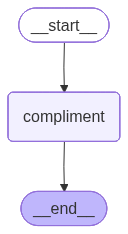

In [20]:
from IPython.display import Image, display

display(Image(application.get_graph().draw_mermaid_png()))

In [25]:
result = application.invoke({"name": "Pranav"})
result["compliment"]

'Pranav, You are doing amazing job learnig langraph?'

# MultiInput Graph
- Multiple Inputs before ending the graph
- Multiple Nodes within graph

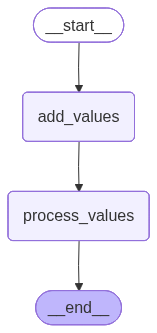

In [34]:
from typing import Dict, TypedDict, List

class AgentState(TypedDict):
    values: List[int]
    result: str
    name: str

def add_values(state: AgentState) -> AgentState:
    """ This function add values"""
    state["values"] = [1, 2, 3, 4, 5]
    return state

def process_values(state: AgentState) -> AgentState:
    """ This function handles multiple inputs"""
    state["result"] = f"Hi, {state['name']} your total bill is {sum(state['values'])}"
    return state

from langgraph.graph import StateGraph, START, END

graph = StateGraph(AgentState)

graph.add_node("process_values", process_values)
graph.add_node("add_values", add_values)
graph.add_edge(START, "add_values")
graph.add_edge("add_values", "process_values")
graph.add_edge("process_values", END)

application = graph.compile()

display(Image(application.get_graph().draw_mermaid_png()))

result = application.invoke({"name": "Pranav"})


In [35]:
result = application.invoke({"name": "Pranav"})
result["result"]

'Hi, Pranav your total bill is 15'

# Conditional graph
- Implementing conditional logic in between nodes
- creating router node to handle decision making and control graph flow.

In [59]:
from typing import Dict, TypedDict, List
from langgraph.graph import StateGraph, START, END
from math import prod

class AgentState(TypedDict):
    operation1: str
    operation2: str
    answer: str
    result: int
    values: List[int]

def add_values(state: AgentState) -> AgentState:
    """ This function add values"""
    state["result"] = state["result"] + sum(state["values"])
    return state

def multiply_values(state: AgentState) -> AgentState:
    """ This function multiply values"""
    state["result"] = state["result"] + prod(state["values"])
    return state

def decide_operation_node1(state: AgentState) -> AgentState:
    """ This function is a decision making node which will decide which operation to perform"""
    if state["operation1"] == "+":
        return "add_operation"
    elif state["operation1"] == "*":
        return "multiply_operation"
    return "add_operation"

def decide_operation_node2(state: AgentState) -> AgentState:
    """ This function is a decision making node which will decide which operation to perform"""
    if state["operation2"] == "+":
        return "add_operation"
    elif state["operation2"] == "*":
        return "multiply_operation"
    return "add_operation"

def finally_node(state: AgentState) -> AgentState:
    """ This function is a finally node which will return the result"""
    state["answer"] = f"The result of the operations are {state['result']}"
    return state


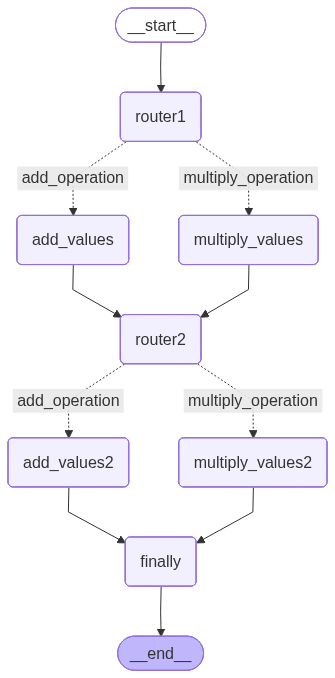

In [60]:
graph = StateGraph(AgentState)

graph.add_node("add_values", add_values)
graph.add_node("multiply_values", multiply_values)
graph.add_node("router1", lambda state: state) # Passthrough function
graph.add_node("router2", lambda state: state) # Passthrough function
graph.add_node("add_values2", add_values)
graph.add_node("multiply_values2", multiply_values)
graph.add_node("finally", finally_node)

graph.add_edge(START, "router1")
graph.add_conditional_edges(
    "router1",
    decide_operation_node1,
    {"add_operation": "add_values", "multiply_operation": "multiply_values"}
)

graph.add_edge("add_values", "router2")
graph.add_edge("multiply_values", "router2")

graph.add_conditional_edges(
    "router2",
    decide_operation_node2,
    {"add_operation": "add_values2", "multiply_operation": "multiply_values2"}
)

graph.add_edge("add_values2", "finally")
graph.add_edge("multiply_values2", "finally")

graph.add_edge("finally", END)

application = graph.compile()

display(Image(application.get_graph().draw_mermaid_png()))


In [61]:
result = application.invoke({"operation1": "*", "values": [1, 2, 3, 4, 5], "operation2": "+", "result": 0})
result["answer"]

'The result of the operations are 135'

# Looping graph
- it helps to implement the looping logic to route the flow of data back to the nodes
- we will create a single conditional edge to handle decision-making and control graph flow

In [70]:
from typing import Dict, TypedDict, List
from langgraph.graph import StateGraph, START, END
import random

class AgentState(TypedDict):
    name: str
    number: List[int]
    counter: int

def greeting_node(state: AgentState) -> AgentState:
    """ This function is a greeting node which will greet the user"""
    state["counter"] = 0
    state["name"] = f"Hello there, {state['name']}"
    return state

def random_node(state: AgentState) -> AgentState:
    """ This function is a random node which will generate a random number from 0 to 10"""
    state["number"].append(random.randint(1, 10))
    state["counter"] += 1
    return state

def should_continue(state: AgentState) -> AgentState:
    """ This function is a decision making node which will decide whether to continue the loop or not"""
    if state["counter"] < 5:
        print(f"Counter is {state['counter']}")
        return "continue"
    else:
        return "exit"

graph = StateGraph(AgentState)



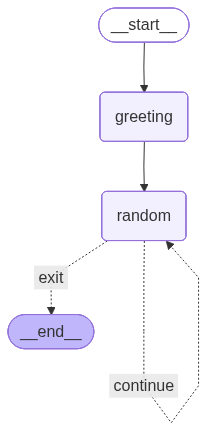

In [71]:
graph.add_node("greeting", greeting_node)
graph.add_node("random", random_node)

graph.add_edge(START, "greeting")
graph.add_edge("greeting", "random")
graph.add_conditional_edges(
    "random",
    should_continue,
    {"continue": "random", "exit": END}
)

application = graph.compile()

display(Image(application.get_graph().draw_mermaid_png()))

# result = application.invoke({"name": "Pranav"})
# result["name"]

In [73]:
import numbers


result = application.invoke({"name": "Pranav", "number": []})
result

Counter is 1
Counter is 2
Counter is 3
Counter is 4


{'name': 'Hello there, Pranav', 'number': [7, 2, 2, 7, 1], 'counter': 5}

# Problem: make a graph for guess game. 
- Set the bounds to between 1 to 20, the graph has to keep guessing ( max guess 7 ) Where if the guess is correcr, then it stops, but if not we keep looping until we hit the max limit of 7
- Each time a number is guessed, the hint node should say higher or lower and the graph should account for this information and guess the next gues accordingly. 

In [ ]:
from typing import Dict, TypedDict, List, Optional
from langgraph.graph import StateGraph, START, END
import random

class AgentState(TypedDict):
    number: int
    guessedNumber: int
    lowerBound: Optional[int] = 1
    upperBound: Optional[int] = 20
    counter: int
    maxCount: Optional[int] = 7
    answer: str

def set_game(state: AgentState) -> AgentState:
    """ This function is setup the game"""
    state["counter"] = 0
    return state

def guess_node(state: AgentState) -> AgentState:
    """ This function is guess the number"""
    state["counter"] += 1
    print(f"Lower bound: {state['lowerBound']}, Upper bound: {state['upperBound']}")
    guessed_number = random.randint(state["lowerBound"], state["upperBound"])
    state["guessedNumber"] = guessed_number
    return state
def hint_node(state: AgentState) -> AgentState:
    """ This function is hint node which will give the hint"""
    if state["guessedNumber"] < state["number"]:
        state["lowerBound"] = state["guessedNumber"]
    else:
        state["upperBound"] = state["guessedNumber"]
    return state

def check_guess_node(state: AgentState) -> AgentState:
    """ This function is check the guess"""
    if state["counter"] > state["maxCount"]:
        return "exit"
    if state["guessedNumber"] == state["number"]:
        return "win"
    else:
        return "guess"

def finally_node(state: AgentState) -> AgentState:
    """ This function is finally node which will return the result"""
    state["answer"] = f"The number got guessed in {state['counter']} guesses, the number was {state['guessedNumber']}"
    return state

def loose_node(state: AgentState) -> AgentState:
    """ This function is loose node which will return the result"""
    state["answer"] = f"You have lost the game, the number was {state['number']}"
    return state

graph = StateGraph(AgentState)
    

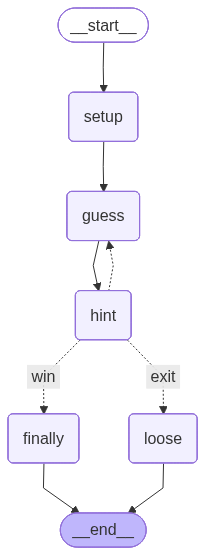

In [84]:
graph.add_node("setup", set_game)
graph.add_node("guess", guess_node) 
graph.add_node("finally", finally_node)
graph.add_node("loose", loose_node)
graph.add_node("hint", hint_node)

graph.add_edge(START, "setup")
graph.add_edge("setup", "guess")
graph.add_edge("guess", "hint")
graph.add_conditional_edges(
    "hint",
    check_guess_node,
    {"win": "finally", "exit": "loose", "guess": "guess"}
)

graph.add_edge("finally", END)
graph.add_edge("loose", END)

application = graph.compile()

display(Image(application.get_graph().draw_mermaid_png()))


In [90]:
result = application.invoke({"number": 10, "lowerBound": 1, "upperBound": 20, "maxCount": 7})
result

Lower bound: 1, Upper bound: 20
Lower bound: 9, Upper bound: 20
Lower bound: 9, Upper bound: 15
Lower bound: 9, Upper bound: 13
Lower bound: 9, Upper bound: 13
Lower bound: 9, Upper bound: 11
Lower bound: 9, Upper bound: 11
Lower bound: 9, Upper bound: 11


{'number': 10,
 'guessedNumber': 11,
 'lowerBound': 9,
 'upperBound': 11,
 'counter': 8,
 'maxCount': 7,
 'answer': 'You have lost the game, the number was 10'}

# AI Agent using Langgraph
## AI agent 1

- The main thing about this implementation is integrating LLM in langgrapg state graph
- It will gave START, processing node, END NODE

In [94]:
from typing import Dict, TypedDict, List, Optional
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from dotenv import load_dotenv 

load_dotenv()

class AgentState(TypedDict):
    messages: List[HumanMessage]

llm = ChatOpenAI(model="gpt-4o")

def process_node(state: AgentState) -> AgentState:
    """ This function is a processing node which will process the messages"""
    messages = state["messages"]
    response = llm.invoke(messages)
    print(f"AI: {response.content}")
    messages.append(response)
    return state

graph = StateGraph(AgentState)

graph.add_node("process", process_node)

graph.add_edge(START, "process")
graph.add_edge("process", END)

application = graph.compile()

result = application.invoke({"messages": [HumanMessage(content="Hello, what is 2 + 2?")]})





    

AI: 2 + 2 equals 4.


## AI Agent II
- Previous agent was onvoking only single time
- In this we will make a chatbot which can stores the previous context to answer the question

In [95]:
from typing import Dict, TypedDict, List, Union
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage
from dotenv import load_dotenv 

load_dotenv()

class AgentState(TypedDict):
    messages: List[Union[HumanMessage, AIMessage]]

llm = ChatOpenAI(model="gpt-4o")

def process_node(state: AgentState) -> AgentState:
    """ This function is a processing node which will process the messages"""
    messages = state["messages"]
    response = llm.invoke(messages)
    print(f"AI: {response.content}")
    messages.append(AIMessage(content=response.content))
    return state

graph = StateGraph(AgentState)

graph.add_node("process", process_node)

graph.add_edge(START, "process")
graph.add_edge("process", END)

application = graph.compile()

conversation_history = []

user_input = input("Enter your message: ")

while user_input != "exit":
    conversation_history.append(HumanMessage(content=user_input))
    result = application.invoke({"messages": conversation_history})
    conversation_history = result["messages"]
    user_input = input("Enter your message: ")





    

AI: Hello! How can I assist you today?
AI: Hi Bob! Nice to meet you. How can I help you today?
AI: Your name is Bob. How can I assist you further?
AI: It sounds like you might be describing a play situation or perhaps giving me a puzzle or riddle involving numbers. Could you clarify or provide more details so I can assist you better?


## AI agent III - ReAct agent
- Reasoning and reacting
- Now agent can use tools to answer user questions
- We will be creating tools 
- We will create ReAct graph
- work with different message type such as ToolMessages
- Test graph robustness

In [ ]:
from typing import Dict, TypedDict, List, Union, Annotated, Sequence
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage, ToolMessage, SystemMessage
from langchain_core.tools import tool
from langgraph.graph import add_messages
from langgraph.prebuilt import ToolNode
from dotenv import load_dotenv 

load_dotenv()

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages] #we created messages so that if we assign new message to it, it will automatically add to the list and don't replace


@tool
def add(a: int, b: int) -> int:
    """This is an addition function which will add two numbers together"""

    print(f"Adding {a} and {b}")
    return a + b

tools = [add]

model = ChatOpenAI(model="gpt-4o").bind_tools(tools)

def model_call(state: AgentState) -> AgentState:
    """This is a model call function which will call the model"""
    system_prompt = SystemMessage(content="You are my AI assistant, please answer my query to the best of your ability")
    response = model.invoke([system_prompt] + state["messages"])
    print(f"AI: {response}")
    return {"messages": [response]}


def should_continue(state: AgentState) -> AgentState:
    messages = state["messages"]
    last_message = messages[-1]
    print("calling conditional edge")
    if not last_message.tool_calls:
        return "end"
    else:
        return "continue"


graph = StateGraph(AgentState)

graph.add_node("our_agent", model_call)

tool_node = ToolNode(tools=tools) #toolNode automatically access the messages from state

graph.add_node("tool_node", tool_node)

graph.add_edge(START, "our_agent")
graph.add_conditional_edges(
    "our_agent",
    should_continue,
    {"continue": "tool_node", "end": END}
)

graph.add_edge("tool_node", "our_agent")

application = graph.compile()

input_message = {"messages": [HumanMessage(content="What is 102.4 + 809? and what is 1024 + 809?")]}

result = application.invoke(input_message)










    



AI: content='' additional_kwargs={'tool_calls': [{'id': 'call_ErsYuMn8qKCMVW8dlubvW96B', 'function': {'arguments': '{"a": 102, "b": 809}', 'name': 'add'}, 'type': 'function'}, {'id': 'call_seE7I9mHQgNdfRnZzPeyEx2V', 'function': {'arguments': '{"a": 1024, "b": 809}', 'name': 'add'}, 'type': 'function'}], 'refusal': None} response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 89, 'total_tokens': 140, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_7a9ae34122', 'id': 'chatcmpl-DRNtLHEIBRucaVU1G9IWtCiHFvZJX', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='run--019d5f39-0a25-7560-93da-937a07a3770c-0' tool_calls=[{'name': 'add', 'args': {'a': 102, 'b': 809}, 'id': 'call_ErsYuMn8qKCMVW8dlubvW96B', 'type': 'tool_call'}, {'na

In [116]:
answer = result["messages"][-1].content
answer
result

{'messages': [HumanMessage(content='What is 102.4 + 809? and what is 1024 + 809?', additional_kwargs={}, response_metadata={}, id='954be570-9464-4431-878e-5e18695c23db'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_ErsYuMn8qKCMVW8dlubvW96B', 'function': {'arguments': '{"a": 102, "b": 809}', 'name': 'add'}, 'type': 'function'}, {'id': 'call_seE7I9mHQgNdfRnZzPeyEx2V', 'function': {'arguments': '{"a": 1024, "b": 809}', 'name': 'add'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 89, 'total_tokens': 140, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_7a9ae34122', 'id': 'chatcmpl-DRNtLHEIBRucaVU1G9IWtCiHFvZJX', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs

# Drafter agent

In [1]:
from typing import Annotated, Sequence, TypedDict
from dotenv import load_dotenv  
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode

load_dotenv()

# This is the global variable to store document content
document_content = ""

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]


@tool
def update(content: str) -> str:
    """Updates the document with the provided content."""
    global document_content
    document_content = content
    return f"Document has been updated successfully! The current content is:\n{document_content}"


@tool
def save(filename: str) -> str:
    """Save the current document to a text file and finish the process.
    
    Args:
        filename: Name for the text file.
    """

    global document_content

    if not filename.endswith('.txt'):
        filename = f"{filename}.txt"


    try:
        with open(filename, 'w') as file:
            file.write(document_content)
        print(f"\n💾 Document has been saved to: {filename}")
        return f"Document has been saved successfully to '{filename}'."
    
    except Exception as e:
        return f"Error saving document: {str(e)}"
    

tools = [update, save]

model = ChatOpenAI(model="gpt-4o").bind_tools(tools)

def our_agent(state: AgentState) -> AgentState:
    system_prompt = SystemMessage(content=f"""
    You are Drafter, a helpful writing assistant. You are going to help the user update and modify documents.
    
    - If the user wants to update or modify content, use the 'update' tool with the complete updated content.
    - If the user wants to save and finish, you need to use the 'save' tool.
    - Make sure to always show the current document state after modifications.
    
    The current document content is:{document_content}
    """)

    if not state["messages"]:
        user_input = "I'm ready to help you update a document. What would you like to create?"
        user_message = HumanMessage(content=user_input)

    else:
        user_input = input("\nWhat would you like to do with the document? ")
        print(f"\n👤 USER: {user_input}")
        user_message = HumanMessage(content=user_input)

    all_messages = [system_prompt] + list(state["messages"]) + [user_message]

    response = model.invoke(all_messages)

    print(f"\n🤖 AI: {response.content}")
    if hasattr(response, "tool_calls") and response.tool_calls:
        print(f"🔧 USING TOOLS: {[tc['name'] for tc in response.tool_calls]}")

    return {"messages": list(state["messages"]) + [user_message, response]}


def should_continue(state: AgentState) -> str:
    """Determine if we should continue or end the conversation."""

    messages = state["messages"]
    
    if not messages:
        return "continue"
    
    # This looks for the most recent tool message....
    for message in reversed(messages):
        # ... and checks if this is a ToolMessage resulting from save
        if (isinstance(message, ToolMessage) and 
            "saved" in message.content.lower() and
            "document" in message.content.lower()):
            return "end" # goes to the end edge which leads to the endpoint
        
    return "continue"

def print_messages(messages):
    """Function I made to print the messages in a more readable format"""
    if not messages:
        return
    
    for message in messages[-3:]:
        if isinstance(message, ToolMessage):
            print(f"\n🛠️ TOOL RESULT: {message.content}")


graph = StateGraph(AgentState)

graph.add_node("agent", our_agent)
graph.add_node("tools", ToolNode(tools))

graph.set_entry_point("agent")

graph.add_edge("agent", "tools")


graph.add_conditional_edges(
    "tools",
    should_continue,
    {
        "continue": "agent",
        "end": END,
    },
)

app = graph.compile()

def run_document_agent():
    print("\n ===== DRAFTER =====")
    
    state = {"messages": []}
    
    for step in app.stream(state, stream_mode="values"):
        if "messages" in step:
            print_messages(step["messages"])
    
    print("\n ===== DRAFTER FINISHED =====")

if __name__ == "__main__":
    run_document_agent()

/Users/pranav.baradkar/Documents/Projects/hugging-face/practice-ai-agent/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(



 ===== DRAFTER =====

🤖 AI: Let's get started. Please tell me what content you would like to add or modify in your document.

👤 USER: make a writeup on virat kohli

🤖 AI: 
🔧 USING TOOLS: ['update']

🛠️ TOOL RESULT: Document has been updated successfully! The current content is:
## Virat Kohli: A Cricketing Legend

### Early Life and Background
Virat Kohli was born on November 5, 1988, in Delhi, India. From a young age, Kohli showed a keen interest in cricket, joining the West Delhi Cricket Academy at the age of 9. His passion and talent for the sport were evident early on, and he quickly rose through the ranks of junior cricket.

### Professional Career
Kohli made his debut for the Indian national team in August 2008 in an ODI match against Sri Lanka. Known for his aggressive playing style and exceptional batting skills, he soon established himself as a key player in the team.

Over the years, Virat Kohli has amassed numerous records and accolades. He became the fastest player to scor